# Chess Evaluations

References:
- Dataset: https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations/data
- Python-chess: https://www.kaggle.com/code/wlifferth/part-1-understanding-python-chess-and-fen
- Chess FEN: https://en.wikipedia.org/wiki/Forsyth%E2%80%93Edwards_Notation

In [1]:
import pandas as pd
import numpy as np
import chess
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import display, Math

In [141]:
DATASET_FILE = "data/chessData.csv"
DATASET_SIZE = 100_000
FEN = "FEN"
EVAL = "Evaluation"

FIG_SIZE = (10, 8)

DATAFRAME_RAW = pd.read_csv(DATASET_FILE, nrows=DATASET_SIZE)

In [142]:
EXAMPLE_GAME_ID = 1000
EXAMPLE_FEN = DATAFRAME_RAW["FEN"][EXAMPLE_GAME_ID]
EXAMPLE_FEN_FIELDS = EXAMPLE_FEN.split(" ")

labels = ["A","B","C","D","E","F"]

parts = [
    rf"\underbrace{{ \text{{{field}}} }}_{{ {label} }}"
    for field, label in zip(EXAMPLE_FEN_FIELDS, labels)
]

board = chess.Board(DATAFRAME_RAW["FEN"][EXAMPLE_GAME_ID])

# FEN

Forsyth–Edwards Notation (FEN) is a standard notation for describing a particular board position of a chess game. The purpose of FEN is to provide all the necessary information to restart a game from a particular position.

A FEN record contains six fields, each separated by a space, e.g.:

<IPython.core.display.Math object>

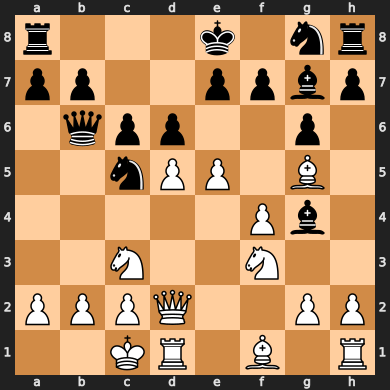

In [143]:
display(Math(r" \quad ".join(parts)))
display(board)

The fields are as follows:

- $A$: Piece placement
    - pawn = "P", knight = "N", bishop = "B", rook = "R", queen = "Q" and king = "K"
    - uppercase letters are white pieces, lowercase black pieces
    - digits from 1 to 8 indicate consecutive empty squares
    - for each rank (rank=row, 8 of them separated by "/") there are all the pieces described, starting from the a file (file=colum)
    - e.g.
- $B$: Active color: "w" for white to move, "b" for black
- $C$: [Castling](https://chess.fandom.com/wiki/Castling) availability
    - indicates which side (if any) can still castle (the right to castle can be lost once the king moves, something that you can't deduce from one single board position)
    - "K" for kingside castle, "Q" for queenside (lower case for black pieces), and "-" for none
- $D$: [En passant](https://chess.fandom.com/wiki/En_passant) target square
    - squares (in algebraic notation) over which a pawn has just passed while moving two squares
    - "-" for no squares
- $E$: Halfmove clock: number of halfmoves since the last capture or pawn advance (used for the [fifty-move rule](https://chess.fandom.com/wiki/Fifty_move_rule))
- $F$: Fullmove number: number of the moves since the beginning of the game

this whole project is about feature engineering, so extracting features from the FEN, blablabla...

In [144]:
from sklearn.preprocessing import FunctionTransformer

# Cleaning

The evaluation feature is a string that contains the [centipawn evaluation](https://chess.fandom.com/wiki/Centipawn), and in the case of forced checkmate in less than 22 moves (the engine's depth), a hashtag is included at the beginning together with the number of moves. This is an edge-case, which is of no interest for our current goals. Moreover, these cases represent less than 1% of the dataset, which is already big enough, so we can just eliminate these rows.

Source: https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations/discussion/497472#2775858

In [173]:
def clean_evaluation(dataframe: pd.DataFrame) -> pd.DataFrame:
    out = dataframe[~dataframe[EVAL].astype(str).str.contains("#")].copy()
    out[EVAL] = pd.to_numeric(out[EVAL], errors="coerce").astype(int)
    return out

clean_evaluation_transformer = FunctionTransformer(clean_evaluation)

In [174]:
DATAFRAME = clean_evaluation_transformer.transform(DATAFRAME_RAW)
DATAFRAME

,FEN,Evaluation
0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,-10
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,56
2,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,-9
3,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...,52
4,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...,-26
...,...,...
99995,rq2r1k1/3n1ppp/4pn2/p2p4/1p1P4/PPNQ2P1/4PPNP/2...,54
99996,rq2r1k1/3n1ppp/4pn2/pN1p4/1p1P4/PP1Q2P1/4PPNP/...,-3
99997,rqr3k1/3n1ppp/4pn2/pN1p4/1p1P4/PP1Q2P1/4PPNP/2...,34
99998,rqr3k1/3n1ppp/4pn2/pN1p4/Pp1P4/1P1Q2P1/4PPNP/2...,17


We also see the evaluation has a vast range of values, but most of them are accumulated around zero.

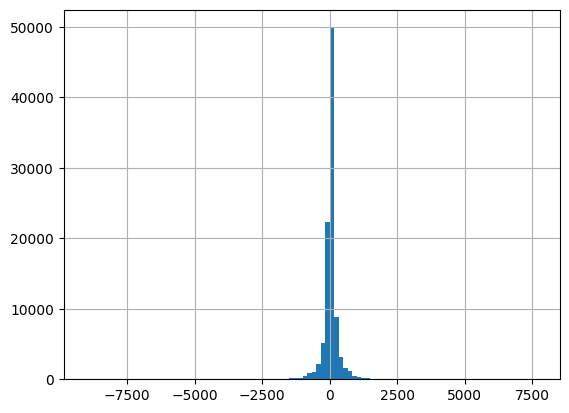

In [175]:
DATAFRAME[EVAL].hist(bins=100)
plt.show()

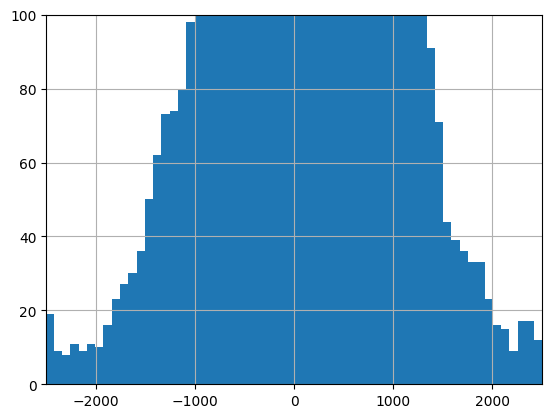

In [176]:
ax = DATAFRAME[EVAL].hist(bins=200)
ax.set_ylim(0, 100)
ax.set_xlim(-2500, 2500)
plt.show()

So we want to either clip them to a maximum (say 1000) or consider them outliers and remove them from the training dataset. For now, we will consider the dataset clipped at 1000.

In [177]:
def handle_extreme_evals(dataframe: pd.DataFrame, threshold: float = 1000, mode: str = "clip") -> pd.DataFrame:
    out = dataframe.copy()
    if mode == "clip":
        out[EVAL] = np.clip(out[EVAL], -threshold, threshold)
    elif mode == "remove":
        out = out[out[EVAL].abs() <= threshold]
    else:
        raise ValueError("mode must be 'clip' or 'remove'")
    return out

extreme_eval_transformer = FunctionTransformer(handle_extreme_evals, kw_args={"threshold": 1000, "mode": "remove"})

In [178]:
DATAFRAME = extreme_eval_transformer.transform(DATAFRAME)

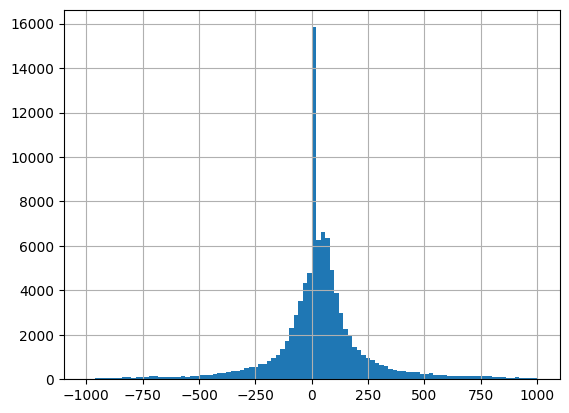

In [179]:
DATAFRAME[EVAL].hist(bins=100)
plt.show()


# Basic Features

The most natural indicator that one would consider to predict the advantage of the players is the piece count: how many pieces does each player have. So, we code the first transformer to extract the piece count from the FEN.

In [194]:
WHITE_PIECES = "WhitePieces"
BLACK_PIECES = "BlackPieces"

In [195]:
def extract_piece_count(dataframe: pd.DataFrame) -> pd.DataFrame:
    out = dataframe.copy()

    def count(fen):
        temp_board = chess.Board(fen)
        white = sum(1 for p in temp_board.piece_map().values() if p.color)
        black = sum(1 for p in temp_board.piece_map().values() if not p.color)
        return white, black

    w, b = zip(*dataframe["FEN"].apply(count))
    out[WHITE_PIECES] = w
    out[BLACK_PIECES] = b

    return out

piece_transformer = FunctionTransformer(extract_piece_count, validate=False)

In [196]:
DATAFRAME = piece_transformer.transform(DATAFRAME)
DATAFRAME

,FEN,Evaluation,WhitePieces,BlackPieces,WhitePieceValue,BlackPieceValue
0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,-10,16,16,3900,3900
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,56,16,16,3900,3900
2,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,-9,16,16,3900,3900
3,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...,52,16,16,3900,3900
4,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...,-26,16,16,3900,3900
...,...,...,...,...,...,...
99995,rq2r1k1/3n1ppp/4pn2/p2p4/1p1P4/PPNQ2P1/4PPNP/2...,54,13,13,3200,3200
99996,rq2r1k1/3n1ppp/4pn2/pN1p4/1p1P4/PP1Q2P1/4PPNP/...,-3,13,13,3200,3200
99997,rqr3k1/3n1ppp/4pn2/pN1p4/1p1P4/PP1Q2P1/4PPNP/2...,34,13,13,3200,3200
99998,rqr3k1/3n1ppp/4pn2/pN1p4/Pp1P4/1P1Q2P1/4PPNP/2...,17,13,13,3200,3200


Right away, we test our simple model with only these basic features. We will be considering a simple Random Forest and Linear Regressor.

In [197]:
FEATURES = [WHITE_PIECES, BLACK_PIECES]

X = DATAFRAME[FEATURES]
y = DATAFRAME[EVAL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Since the dataset is fairly balanced (54%-37), we will consider the plain sign accuracy of our prediction. For now, we are just checking the evaluation's sign because the RMSE is not yet a good indicator for model fitness.

In [198]:
pd.cut(DATAFRAME[EVAL],
    bins=[-float("inf"), -1, 0, float("inf")],
    labels=["black", "draw", "white"]).value_counts(normalize=True) * 100

Evaluation
white    56.153957
black    32.927132
draw     10.918911
Name: proportion, dtype: float64

In [199]:
def sign_accuracy(y_true, y_pred):
    true_sign = np.sign(y_true)
    pred_sign = np.sign(y_pred)

    true_sign[true_sign == 0] = 0
    pred_sign[pred_sign == 0] = 0

    correct = np.sum(true_sign == pred_sign)
    return correct / len(y_true)

def sign_recall(y_true, y_pred, player: str = "white"):
    true_sign = np.sign(y_true)
    pred_sign = np.sign(y_pred)

    if player == "white":
        mask = true_sign > 0
    elif player == "black":
        mask = true_sign < 0
    elif player == "draw":
        mask = true_sign == 0
    else:
        raise ValueError("player must be 'white' or 'black'")

    if mask.sum() == 0:
        return np.nan

    return np.sum(pred_sign[mask] == true_sign[mask]) / np.sum(mask)

def centipawn_accuracy(y_true, y_pred, tol=100):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    correct = np.abs(y_true - y_pred) <= tol
    return np.mean(correct)


def metrics(y_p, y_t, tol: int = 100):
    mse = mean_squared_error(y_t, y_p)
    acc = sign_accuracy(y_t, y_p)
    recall_pos = sign_recall(y_t, y_p, "white")
    recall_neg = sign_recall(y_t, y_p, "black")
    acc_cp = centipawn_accuracy(y_t, y_p, tol)

    print("Mean Squared Error:", mse)
    print("Sign accuracy:", acc)
    print("Positive sign recall:", recall_pos)
    print("Negative sign recall:", recall_neg)
    print(f"Centipawn ±{tol} accuracy:", acc_cp)

    plt.figure(figsize=FIG_SIZE)
    plt.scatter(y_t, y_p)
    plt.show()

def plot_eval(df, model, f1, f2):
    w_vals = np.linspace(df[f1].min(), df[f1].max(), 100)
    b_vals = np.linspace(df[f2].min(), df[f2].max(), 100)
    W, B = np.meshgrid(w_vals, b_vals)

    grid_df = pd.DataFrame({f1: W.ravel(), f2: B.ravel()})
    Z = model.predict(grid_df).reshape(W.shape)

    plt.figure(figsize=FIG_SIZE)
    contour = plt.contourf(W, B, Z, levels=50, cmap="viridis")
    plt.colorbar(contour, label="Predicted Evaluation (centipawns)")

    zero_line = plt.contour(W, B, Z, levels=[0], colors="white")
    plt.clabel(zero_line, fmt="0", fontsize=10)

    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.title("Predicted Evaluation")

    plt.show()

Mean Squared Error: 42796.5456217484
Sign accuracy: 0.5970981566582331
Positive sign recall: 0.913380022115739
Negative sign recall: 0.25881247062509793
Centipawn ±100 accuracy: 0.6172871379150101


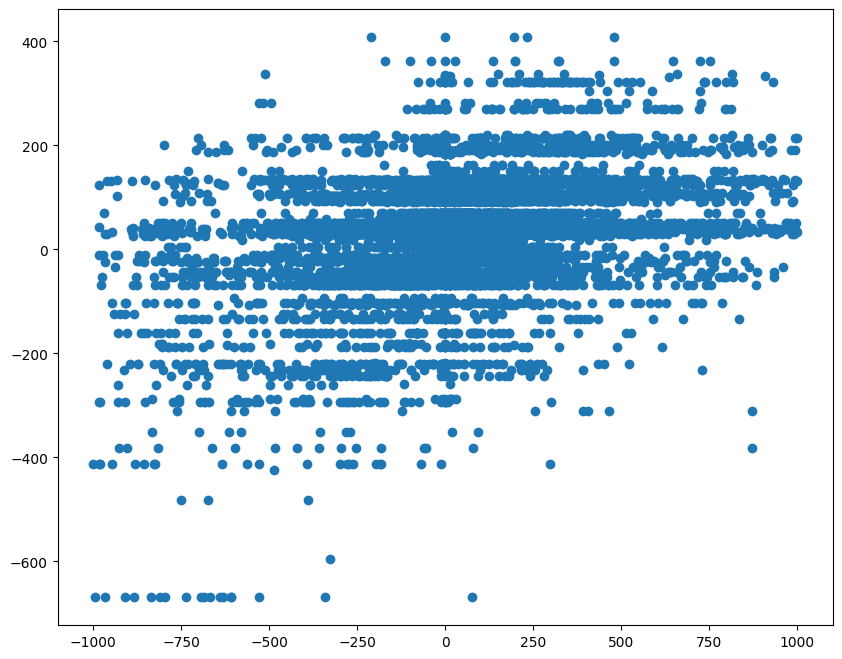

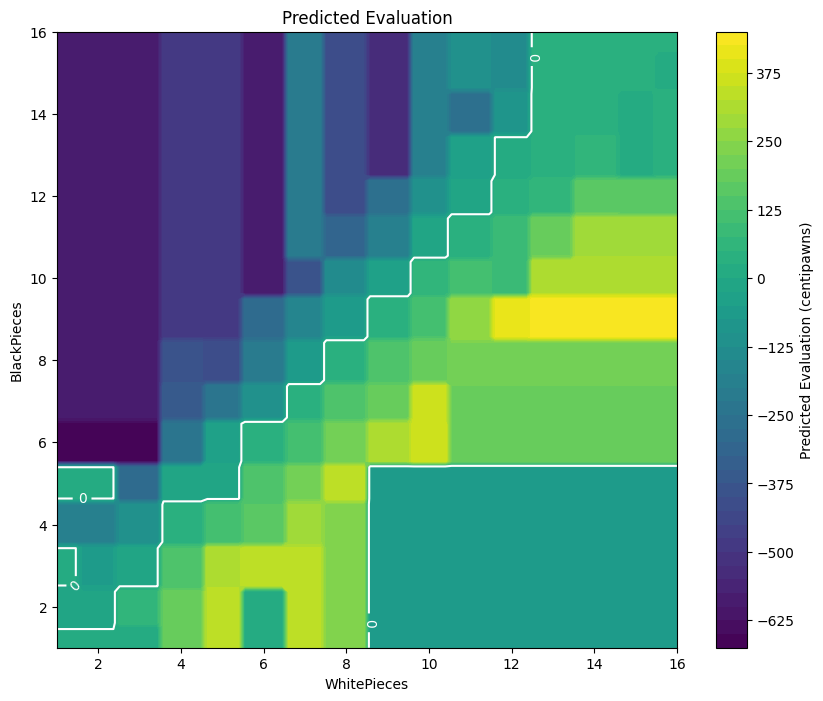

In [200]:
model = GradientBoostingRegressor(max_depth=16)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
metrics(y_pred, y_test)
plot_eval(X_train, model, WHITE_PIECES, BLACK_PIECES)

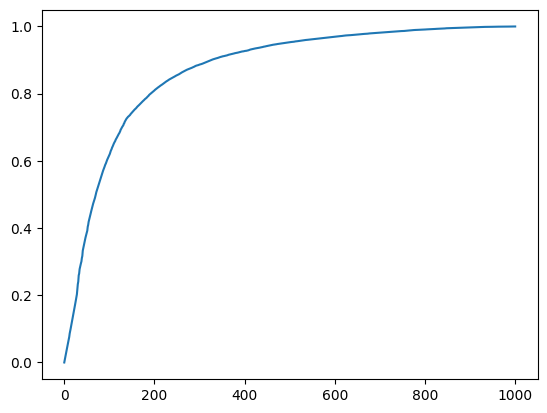

In [206]:
cp = np.linspace(0, 1000, 1000)
m = [centipawn_accuracy(y_test, y_pred, x) for x in cp]

plt.plot(cp, m)
plt.show()

# Piece values

Source: https://chess.fandom.com/wiki/Value

In [207]:
PIECE_VALUATIONS = {
    "standard": {
        chess.PAWN: 100,
        chess.KNIGHT: 300,
        chess.BISHOP: 300,
        chess.ROOK: 500,
        chess.QUEEN: 900,
        chess.KING: 0
    },
    "Jacob Sarratt's": {
        chess.PAWN: 100,
        chess.KNIGHT: 462,
        chess.BISHOP: 487,
        chess.ROOK: 750,
        chess.QUEEN: 1187,
        chess.KING: 0
    }
}

In [208]:
WHITE_PIECES_VALUE = "WhitePieceValue"
BLACK_PIECES_VALUE = "BlackPieceValue"

def extract_piece_values(dataframe: pd.DataFrame, valuation: str = "standard") -> pd.DataFrame:
    out = dataframe.copy()

    def piece_score(fen):
        temp_board = chess.Board(fen)
        white_score = 0
        black_score = 0

        for p in temp_board.piece_map().values():
            value = PIECE_VALUATIONS[valuation][p.piece_type]
            if p.color:
                white_score += value
            else:
                black_score += value

        return white_score, black_score

    w_val, b_val = zip(*dataframe[FEN].apply(piece_score))

    out[WHITE_PIECES_VALUE] = w_val
    out[BLACK_PIECES_VALUE] = b_val

    return out

piece_value_transformer = FunctionTransformer(extract_piece_values, validate=False)

In [209]:
DATAFRAME = piece_value_transformer.transform(DATAFRAME)
DATAFRAME

,FEN,Evaluation,WhitePieces,BlackPieces,WhitePieceValue,BlackPieceValue
0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,-10,16,16,3900,3900
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,56,16,16,3900,3900
2,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,-9,16,16,3900,3900
3,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...,52,16,16,3900,3900
4,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...,-26,16,16,3900,3900
...,...,...,...,...,...,...
99995,rq2r1k1/3n1ppp/4pn2/p2p4/1p1P4/PPNQ2P1/4PPNP/2...,54,13,13,3200,3200
99996,rq2r1k1/3n1ppp/4pn2/pN1p4/1p1P4/PP1Q2P1/4PPNP/...,-3,13,13,3200,3200
99997,rqr3k1/3n1ppp/4pn2/pN1p4/1p1P4/PP1Q2P1/4PPNP/2...,34,13,13,3200,3200
99998,rqr3k1/3n1ppp/4pn2/pN1p4/Pp1P4/1P1Q2P1/4PPNP/2...,17,13,13,3200,3200


Mean Squared Error: 34019.77462989416
Sign accuracy: 0.6301956937057882
Positive sign recall: 0.930243273129377
Negative sign recall: 0.3305655647814507
Centipawn ±100 accuracy: 0.6506944803015439


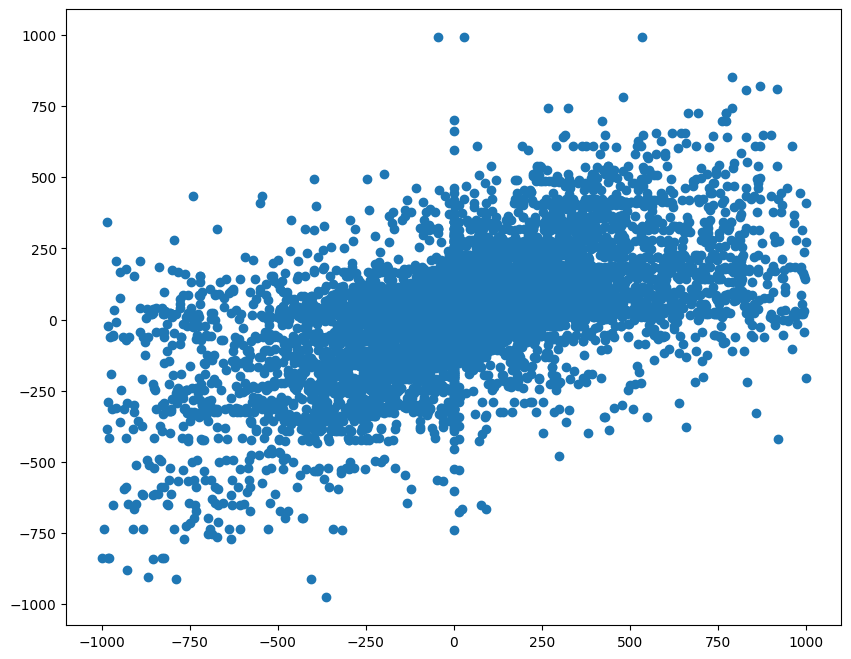

In [210]:
FEATURES = [WHITE_PIECES, BLACK_PIECES, WHITE_PIECES_VALUE, BLACK_PIECES_VALUE]

X = DATAFRAME[FEATURES]
y = DATAFRAME[EVAL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(max_depth=16)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
metrics(y_pred, y_test)

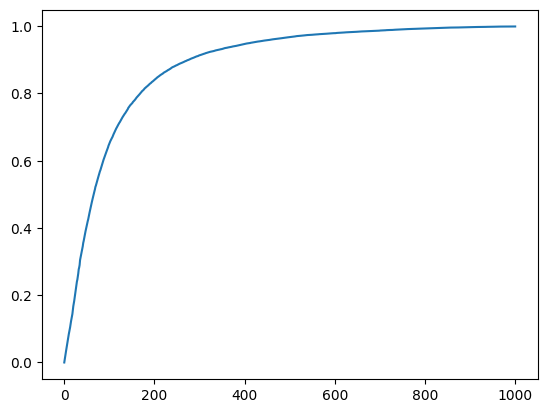

In [220]:
cp = np.linspace(0, 1000, 1000)
m = [centipawn_accuracy(y_test, y_pred, x) for x in cp]

plt.plot(cp, m)
plt.show()

# Predicted Piece Values

In [230]:
def extract_piece_type_count(dataframe: pd.DataFrame) -> pd.DataFrame:
    out = dataframe.copy()

    def count_types(fen):
        board = chess.Board(fen)
        piece_map = board.piece_map()

        # result dict { "White_PAWN": n, "Black_PAWN": n, ... }
        counts = {}

        for ptype in (
            chess.PAWN,
            chess.KNIGHT,
            chess.BISHOP,
            chess.ROOK,
            chess.QUEEN,
            chess.KING
        ):
            w = sum(1 for p in piece_map.values() if p.piece_type == ptype and p.color)
            b = sum(1 for p in piece_map.values() if p.piece_type == ptype and not p.color)
            counts[f"White_{chess.piece_name(ptype).capitalize()}"] = w
            counts[f"Black_{chess.piece_name(ptype).capitalize()}"] = b

        return counts

    # expand dict outputs into columns
    feature_dicts = dataframe["FEN"].apply(count_types)
    feature_df = pd.DataFrame(feature_dicts.tolist(), index=dataframe.index)

    out = pd.concat([out, feature_df], axis=1)
    return out

piece_type_transformer = FunctionTransformer(extract_piece_type_count, validate=False)
temp = piece_type_transformer.transform(DATAFRAME)

Mean Squared Error: 27990.05385162459
Sign accuracy: 0.6574585635359116
Positive sign recall: 0.9197382970880944
Negative sign recall: 0.4311452295159016
Centipawn ±100 accuracy: 0.688387463210616


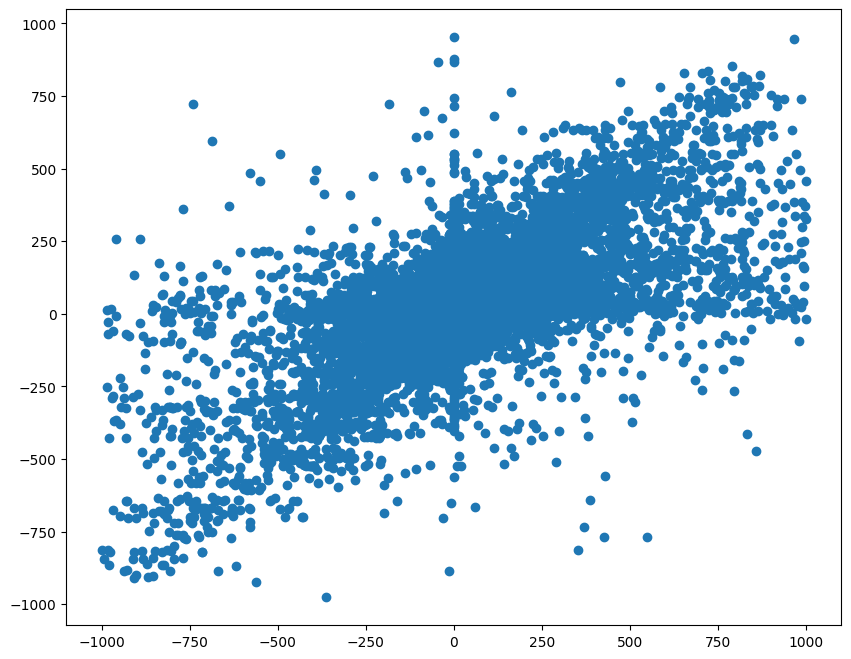

In [231]:
FEATURES = ["White_Pawn", "Black_Pawn", "White_Knight", "Black_Knight", "White_Bishop", "Black_Bishop", "White_Rook", "Black_Rook", "White_Queen", "Black_Queen", "White_King", "Black_King"]

X = temp[FEATURES]
y = temp[EVAL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(max_depth=16)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
metrics(y_pred, y_test)

In [232]:
importances = model.feature_importances_
for name, imp in zip(X_train.columns, importances):
    print(name, imp)

White_Pawn 0.10413162586757356
Black_Pawn 0.14418271756939346
White_Knight 0.12206617713324819
Black_Knight 0.117910349397763
White_Bishop 0.11972236859437982
Black_Bishop 0.09631904364532647
White_Rook 0.10371209170846493
Black_Rook 0.0958275995996045
White_Queen 0.04872398897518755
Black_Queen 0.04740403750905865
White_King 0.0
Black_King 0.0


Mean Squared Error: 42251.51011284365
Sign accuracy: 0.5988537202457789
Positive sign recall: 0.8803907113896056
Negative sign recall: 0.3202255992480025
Centipawn ±100 accuracy: 0.5967883513192545


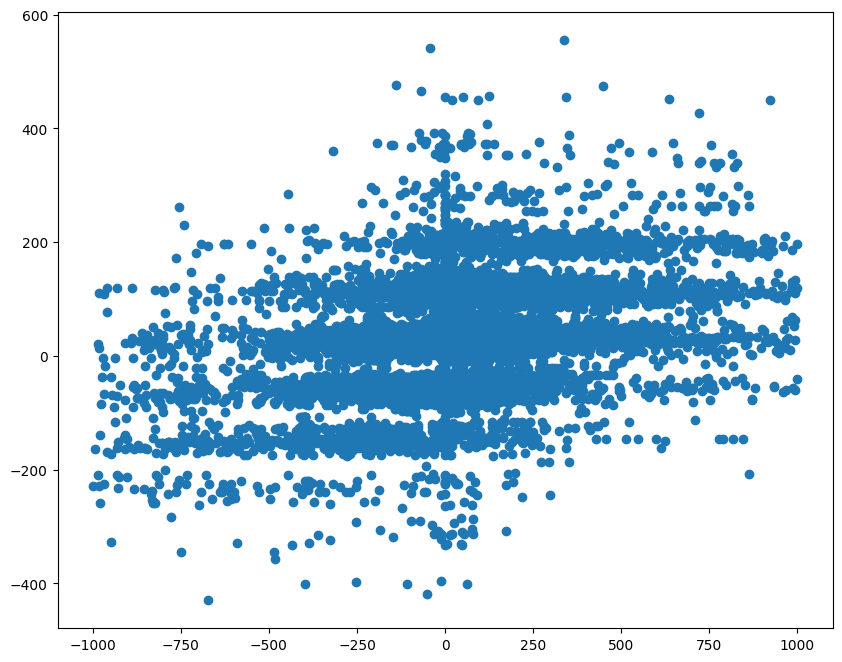

In [233]:
FEATURES = [x for x in temp.columns if x not in ["Evaluation", "FEN"]]

X = temp[FEATURES]
y = temp[EVAL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
metrics(y_pred, y_test)

In [234]:
coefs = pd.Series(model.coef_, index=X_train.columns)
intercept = model.intercept_

print(coefs)
print("intercept:", intercept)

WhitePieces        10.943330
BlackPieces       -11.519761
WhitePieceValue     0.357724
BlackPieceValue    -0.353988
White_Pawn         41.028807
Black_Pawn        -38.168396
White_Knight      -27.852334
Black_Knight       22.201465
White_Bishop       -5.409903
Black_Bishop        7.348621
White_Rook         -7.542659
Black_Rook          6.093084
White_Queen        10.719419
Black_Queen        -8.994536
White_King          0.000000
Black_King          0.000000
dtype: float64
intercept: 14.090462194517762


In [235]:
piece_types = ["Pawn","Knight","Bishop","Rook","Queen","King"]

avg_abs = {}
for p in piece_types:
    cols = [c for c in coefs.index if p in c]
    vals = coefs[cols].abs()
    avg_abs[p] = vals.mean()

avg_abs = pd.Series(avg_abs)

# linear rescale: Pawn -> 100, Queen -> 900
pawn_val = avg_abs["Pawn"]
queen_val = avg_abs["Queen"]

scale = (900 - 100) / (queen_val - pawn_val)
shift = 100 - pawn_val * scale

normalized = avg_abs * scale + shift
normalized

Pawn       100.000000
Knight     491.954443
Bishop     993.544737
Rook       981.746884
Queen      900.000000
King      1165.136241
dtype: float64

---

Mean Squared Error: 21274.594222957225
Sign accuracy: 0.7350131667269066
Positive sign recall: 0.8830630298562477
Negative sign recall: 0.7288109039636534
Centipawn ±100 accuracy: 0.7594361542830588


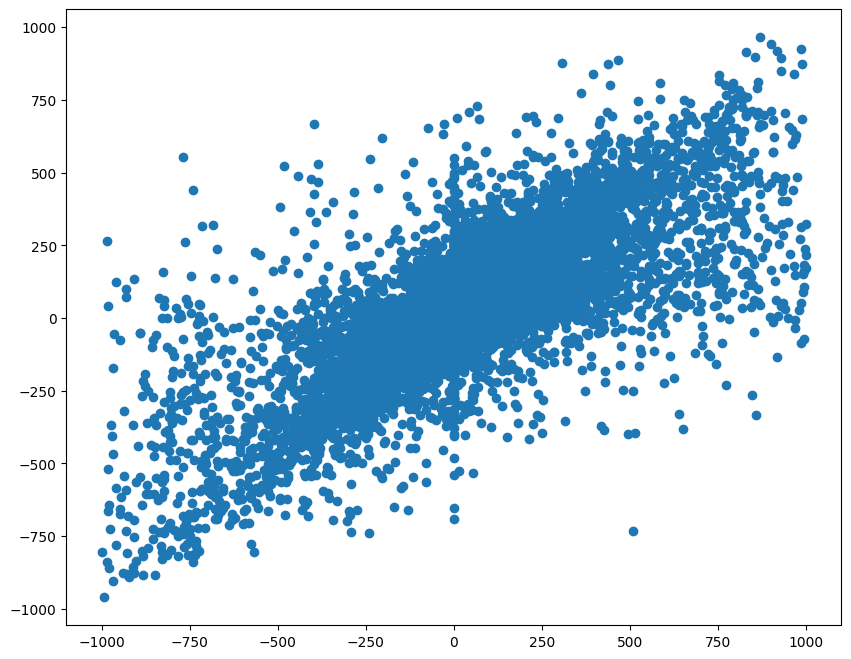

In [228]:
# xat
PIECE_VALUES = {
    chess.PAWN: 1.0,
    chess.KNIGHT: 3.0,
    chess.BISHOP: 3.0,
    chess.ROOK: 5.0,
    chess.QUEEN: 9.0,
    chess.KING: 0.0
}

CENTRAL_SQUARES = {chess.E4, chess.D4, chess.E5, chess.D5}

def is_passed_pawn(board, square, color):
    file = chess.square_file(square)
    rank = chess.square_rank(square)
    if color == chess.WHITE:
        # any black pawn on same or adjacent file ahead (higher ranks)?
        for r in range(rank + 1, 8):
            for f in (file - 1, file, file + 1):
                if 0 <= f < 8:
                    sq = chess.square(f, r)
                    piece = board.piece_type_at(sq)
                    if piece == chess.PAWN and not board.color_at(sq):
                        return False
        return True
    else:
        # black pawn: look for white pawns ahead (lower ranks)
        for r in range(rank - 1, -1, -1):
            for f in (file - 1, file, file + 1):
                if 0 <= f < 8:
                    sq = chess.square(f, r)
                    piece = board.piece_type_at(sq)
                    if piece == chess.PAWN and board.color_at(sq):
                        return False
        return True

def pawn_stats(board, color):
    pawns = [sq for sq, piece in board.piece_map().items() if piece.piece_type == chess.PAWN and piece.color == color]
    files = {}
    doubled = 0
    isolated = 0
    passed = 0
    for sq in pawns:
        f = chess.square_file(sq)
        files.setdefault(f, 0)
        files[f] += 1
    doubled = sum(count - 1 for count in files.values() if count > 1)
    # isolated: file has pawns ==1 and no pawns on adjacent files
    for f, count in files.items():
        if count == 1 and files.get(f - 1, 0) == 0 and files.get(f + 1, 0) == 0:
            isolated += 1
    for sq in pawns:
        if is_passed_pawn(board, sq, color):
            passed += 1
    pawn_islands = 0
    sorted_files = sorted(files.keys())
    if sorted_files:
        prev = sorted_files[0] - 2
        for f in sorted_files:
            if f != prev + 1:
                pawn_islands += 1
            prev = f
    return {"doubled": doubled, "isolated": isolated, "passed": passed, "islands": pawn_islands}

def extract_features_from_fen(fen: str) -> dict:
    b = chess.Board(fen)
    features = {}
    # counts and material
    for color, prefix in ((chess.WHITE, "W_"), (chess.BLACK, "B_")):
        mat = 0.0
        for ptype in (chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING):
            cnt = len([1 for sq, pc in b.piece_map().items() if pc.piece_type == ptype and pc.color == color])
            features[f"{prefix}count_{ptype}"] = cnt
            mat += cnt * PIECE_VALUES[ptype]
        features[f"{prefix}material"] = mat
        # bishop pair
        features[f"{prefix}bishop_pair"] = int(features[f"{prefix}count_{chess.BISHOP}"] >= 2)
    # material diff and total
    features["mat_diff"] = features["W_material"] - features["B_material"]
    features["mat_total"] = features["W_material"] + features["B_material"]

    # mobility: legal moves for each side
    b_white = b.copy()
    b_white.turn = True
    features["mobility_white"] = len(list(b_white.legal_moves))
    b_black = b.copy()
    b_black.turn = False
    features["mobility_black"] = len(list(b_black.legal_moves))
    # mobility for side to move
    features["mobility_to_move"] = len(list(b.legal_moves))

    # king safety: attackers on king and in king zone
    wk_sq = b.king(chess.WHITE)
    bk_sq = b.king(chess.BLACK)
    features["W_king_attackers"] = 0 if wk_sq is None else len(b.attackers(chess.BLACK, wk_sq))
    features["B_king_attackers"] = 0 if bk_sq is None else len(b.attackers(chess.WHITE, bk_sq))
    # king zone attackers
    def king_zone_attackers(board, king_sq, attacker_color):
        if king_sq is None:
            return 0
        zone = [king_sq] + [n for n in chess.SQUARES if chess.square_distance(king_sq, n) == 1]
        return sum(len(board.attackers(attacker_color, sq)) for sq in zone)
    features["W_king_zone_attackers"] = king_zone_attackers(b, wk_sq, chess.BLACK)
    features["B_king_zone_attackers"] = king_zone_attackers(b, bk_sq, chess.WHITE)

    # pawn structure features
    pw = pawn_stats(b, chess.WHITE)
    pb = pawn_stats(b, chess.BLACK)
    for k, v in pw.items():
        features[f"W_pawn_{k}"] = v
    for k, v in pb.items():
        features[f"B_pawn_{k}"] = v

    # center control: attacks on central squares
    features["center_control_white"] = sum(1 for sq in CENTRAL_SQUARES if b.is_attacked_by(chess.WHITE, sq))
    features["center_control_black"] = sum(1 for sq in CENTRAL_SQUARES if b.is_attacked_by(chess.BLACK, sq))

    # central piece presence
    features["W_central_pieces"] = sum(1 for sq, pc in b.piece_map().items() if pc.color == chess.WHITE and sq in CENTRAL_SQUARES)
    features["B_central_pieces"] = sum(1 for sq, pc in b.piece_map().items() if pc.color == chess.BLACK and sq in CENTRAL_SQUARES)

    # castling rights and en-passant
    features["W_can_castle_kingside"] = int(b.has_kingside_castling_rights(chess.WHITE))
    features["W_can_castle_queenside"] = int(b.has_queenside_castling_rights(chess.WHITE))
    features["B_can_castle_kingside"] = int(b.has_kingside_castling_rights(chess.BLACK))
    features["B_can_castle_queenside"] = int(b.has_queenside_castling_rights(chess.BLACK))
    features["has_ep"] = int(b.ep_square is not None)
    features["in_check"] = int(b.is_check())

    # move counters / phase
    features["halfmove_clock"] = b.halfmove_clock
    features["fullmove_number"] = b.fullmove_number
    initial_total = sum(v * cnt for v, cnt in [
        (PIECE_VALUES[chess.PAWN], 16),
        (PIECE_VALUES[chess.KNIGHT], 4),
        (PIECE_VALUES[chess.BISHOP], 4),
        (PIECE_VALUES[chess.ROOK], 4),
        (PIECE_VALUES[chess.QUEEN], 2),
    ])
    features["phase"] = (features["mat_total"] / initial_total) if initial_total > 0 else 0.0

    # side to move
    features["side_to_move_white"] = int(b.turn)

    return features

rows = [extract_features_from_fen(fen) for fen in DATAFRAME["FEN"]]
X = pd.DataFrame(rows)
y = DATAFRAME[EVAL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(max_depth=16)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
metrics(y_pred, y_test)